Breast Cancer – классификация опухоли как доброкачественной либо
злокачественной в зависимости от характеристик образцов биопсии.

https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Original)

Данные в cancer_dataset. 9 входных признаков:  
1. Clump thickness - Толщина комка
2. Uniformity of cell size - Однородность размера ячеек
3. Uniformity of cell shape - Однородность формы ячейки
4. Marginal Adhesion - Маргинальная адгезия
5. Single epithelial cell size - Размер одной эпителиальной клетки
6. Bare nuclei - Голые ядра
7. Bland chomatin - Блэнд Хроматин
8. Normal nucleoli - Нормальные нуклеолы
9. Mitoses - Митозы

и 2 выхода (доброкачественная/злокачественная)

## Пояснялкины

В ходе лабораторной работы заметим, что оказывается сам датасет представлены в виде транспонированной таблицы, т.к. если выводить через функцию .shape, то увидим следующие моменты:

print(data['cancerInputs']) -> (9, 699)

print(data['cancerTargets']) -> (2, 699)

В таблице cancerTargets используются две строки, где
*   Первая строка [1, 0] - это незлокачественная - не больной
*   Вторая строка [0, 1] - это злокачественная - больной

Обработаем этот случай при помощи функции argmax(m_in, axis, m_out=None)



### Посхалкины

Так как таблица cancerTargets и cancerInputs имеют значения от 0 до 1, то нет необходимости к нормализации данных

### Дополнительная полезная ифнормация

Ссылка на статью в Habr о том, что такое сеть обратного распространения: https://habr.com/ru/companies/otus/articles/483466/

Ссылка на датасет:
https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

In [ ]:
#Подключение к Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.io


from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [ ]:
file_path = '/content/drive/My Drive/Colab Notebooks/cd.mat'
data = scipy.io.loadmat(file_path)

In [ ]:
attribute_data = [ "Толщина комка",
                 "Однородность размера ячеек",
                 "Однородность формы ячейки",
                 "Маргинальная адгезия",
                 "Размер одной эпителиальной клетки",
                 "Голые ядра",
                 "Блэнд Хроматин",
                 "Нормальные нуклеолы",
                 "Митозы"]

example_x = pd.DataFrame(data['cancerInputs'].T, columns=attribute_data)
print(example_x.head())

   Толщина комка  Однородность размера ячеек  Однородность формы ячейки  \
0            0.2                         0.1                        0.1   
1            0.2                         0.1                        0.1   
2            0.5                         0.1                        0.1   
3            0.5                         0.4                        0.6   
4            0.5                         0.3                        0.3   

   Маргинальная адгезия  Размер одной эпителиальной клетки  Голые ядра  \
0                   0.1                                0.2         0.1   
1                   0.1                                0.2         0.1   
2                   0.1                                0.2         0.1   
3                   0.8                                0.4         0.1   
4                   0.1                                0.2         0.1   

   Блэнд Хроматин  Нормальные нуклеолы  Митозы  
0             0.2                  0.1     0.1  
1     

In [ ]:
print("\nСтатистика по датасету:")
print(example_x.describe())


Статистика по датасету:
       Толщина комка  Однородность размера ячеек  Однородность формы ячейки  \
count     699.000000                  699.000000                 699.000000   
mean        0.441774                    0.313448                   0.320744   
std         0.281574                    0.305146                   0.297191   
min         0.100000                    0.100000                   0.100000   
25%         0.200000                    0.100000                   0.100000   
50%         0.400000                    0.100000                   0.100000   
75%         0.600000                    0.500000                   0.500000   
max         1.000000                    1.000000                   1.000000   

       Маргинальная адгезия  Размер одной эпителиальной клетки  Голые ядра  \
count            699.000000                         699.000000  699.000000   
mean               0.280687                           0.321602    0.354363   
std                0.285538  

In [ ]:
X = data['cancerInputs'].T
Y = data['cancerTargets'].T

In [ ]:
y_labes = np.argmax(data['cancerTargets'], axis=0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=y_labes)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print("\n Первые 5 строк обучающего набора:")
print(X_train[:5])
print("\n Соответствующие им метки классов (y):")
print(y_train[:5])

(559, 9)
(140, 9)

 Первые 5 строк обучающего набора:
[[0.7  0.4  0.5  1.   0.2  1.   0.3  0.8  0.2 ]
 [0.6  0.1  0.1  0.3  0.2  0.1  0.1  0.1  0.1 ]
 [0.5  0.1  0.1  0.1  0.2  0.2  0.2  0.1  0.1 ]
 [0.1  0.1  0.1  0.1  0.2  0.4  0.1  0.1  0.1 ]
 [0.8  0.4  0.5  0.1  0.2  0.35 0.7  0.3  0.1 ]]

 Соответствующие им метки классов (y):
[[0 1]
 [1 0]
 [1 0]
 [1 0]
 [0 1]]


### Функции активации

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
  return x * (1 - x)

def relu(x):
  return np.maximum(0, x)
def relu_derivative(x):
  return np.where(x > 0, 1, 0)

### Реализуем функцию обратного распространения и посмотрим

In [ ]:
# 9 входов + 1 (bias), H нейронов в скрытом слое
H = 10
W1 = np.random.randn(10, H) * 0.1
W2 = np.random.randn(H + 1, 2) * 0.1
etta = 0.1

Функция взята из примера предоставленная преподавателем и полностью мною разобрана:

----
Представление сети:

Здесь представлена однослоная сеть, в котором всего есть 9 признаков - т.е. 9 нейронов входов + 1 нейрон-биас (смещение)

На скрытом слое уже представлены 10 признаков, кроме этого, к нему также добавляется смещение для корректировки весов - по итогу всего 11 признаков

На выходе подается 2 признака с сигналами:
* [0 1] 0 - болен / 1 - не болен
* [1 0] 1 - болен / 0 - не болен
----

Разбор функции:

Вход:
*   W1 - веса для скрытого слоя
*   W2 - веса для выходного слоя
*   input - значение признаков из cancerInputs
*   output - целевые значения из cancerTargets

Выход:
*   Обновление весов W1, W2
*   Квадратическая ошибка

In [ ]:
def my_BackProp(W1, W2, input, output):
  #добавление смещения для скрытого слоя
  z_2 = np.append(input, -1)

  #Скрытый слой
  a_2 = sigmoid(np.dot(z_2, W1))
  a_2_bias = np.append(a_2, -1)

  #Выходной слой
  s = sigmoid(np.dot(a_2_bias, W2))

  #Перед тем, как обратно идти -> найдем ошибку
  #Вычисление ошибки
  error = s - output

  #Обратный ход - к скрытому слою
  delta = error*sigmoid_derivative(s)

  #Вычисление весов в скрытом слое
  hidden_weight_s = np.dot(delta, W2[:-1, :].T)
  delta_hidden_s = hidden_weight_s * sigmoid_derivative(a_2)

  #Обновление весов
  NewW2 = W2 - etta*np.outer(a_2_bias, delta)
  NewW1 = W1 - etta*np.outer(z_2, delta_hidden_s)

  return NewW1, NewW2, np.sum(error**2)

### Проверка работоспособности

Ниже представлена обучение модели

In [ ]:
epochs = 100
errors = []

for epoch in range(epochs):
    epoch_error = 0
    for i in range(len(X_train)):
        input_vec = X_train[i]
        target_vec = y_train[i]

        W1, W2, err = my_BackProp(W1, W2, input_vec, target_vec)
        epoch_error += err

    errors.append(epoch_error / len(X_train))
    if epoch % 10 == 0:
        print(f"Эпоха {epoch}, Средняя ошибка: {errors[-1]:.4f}")

Эпоха 0, Средняя ошибка: 0.4483
Эпоха 10, Средняя ошибка: 0.0554
Эпоха 20, Средняя ошибка: 0.0492
Эпоха 30, Средняя ошибка: 0.0475
Эпоха 40, Средняя ошибка: 0.0466
Эпоха 50, Средняя ошибка: 0.0460
Эпоха 60, Средняя ошибка: 0.0456
Эпоха 70, Средняя ошибка: 0.0453
Эпоха 80, Средняя ошибка: 0.0450
Эпоха 90, Средняя ошибка: 0.0448


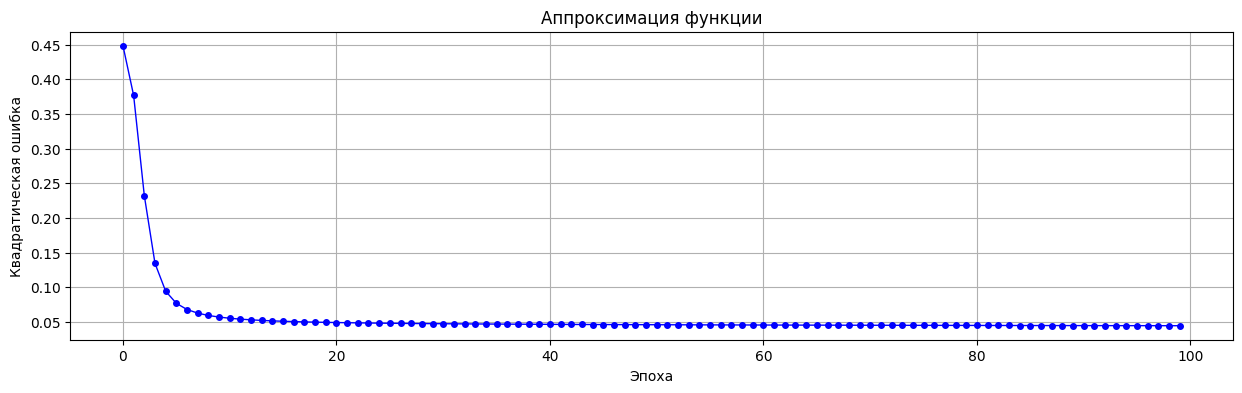

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(range(epochs), errors, 'b.-', markersize=8, linewidth=1, label='')
plt.xlabel('Эпоха')
plt.ylabel('Квадратическая ошибка')
plt.title('Аппроксимация функции')
plt.grid(True)
plt.show()

In [ ]:
print(W1)
print()
print(W2)

[[-1.37292078 -1.40446425 -1.08133189 -1.2864093   1.74369801 -0.38818803
  -1.25391053 -1.24035199 -0.27386851 -0.93535898]
 [-0.45021885 -0.59462082 -0.54430383 -0.65914911  0.772299   -0.1459213
  -0.57288024 -0.60008821 -0.11324556 -0.28430645]
 [-0.56621461 -0.52081746 -0.5516415  -1.05303707  0.98210302 -0.2175515
  -0.75914814 -0.56027928 -0.22164116 -0.52502763]
 [-0.73541139 -0.84103911 -0.69336773 -0.79735984  1.09855517 -0.32398641
  -0.82270734 -0.84022854 -0.25617175 -0.7180657 ]
 [ 0.03203737  0.22498202  0.04421174 -0.47433124  0.17993431 -0.10836532
  -0.10493265 -0.1636795   0.02306371 -0.24911614]
 [-1.022467   -1.32148517 -1.29269959 -1.56430041  1.87434416 -0.30561353
  -1.47185452 -1.19598481 -0.22032614 -1.18005146]
 [-0.60120368 -0.72158312 -0.54379397 -0.78879898  0.8678555  -0.38468964
  -0.64569583 -0.62255821 -0.16802041 -0.54984943]
 [-0.25602163 -0.22136626 -0.27315841 -0.78711856  0.65463092 -0.04741869
  -0.48095048 -0.41407845 -0.17123307 -0.53253602]
 [

Ниже представлена точность предсказанной модели со всей выборки

In [ ]:
correct = 0

y_true = []
y_pred = []

for i in range(len(X_test)):
    x_bias = np.append(X_test[i], -1)
    u = sigmoid(np.dot(x_bias, W1))
    u_bias = np.append(u, -1)
    a = sigmoid(np.dot(u_bias, W2))

    if np.argmax(a) == np.argmax(y_test[i]):
        correct += 1

    y_true.append(np.argmax(y_test[i]))
    y_pred.append(np.argmax(a))

accuracy = (correct / len(X_test)) * 100
print(f"Точность на тестовых данных: {accuracy:.2f}%")

Точность на тестовых данных: 97.86%


In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        92
           1       0.94      1.00      0.97        48

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



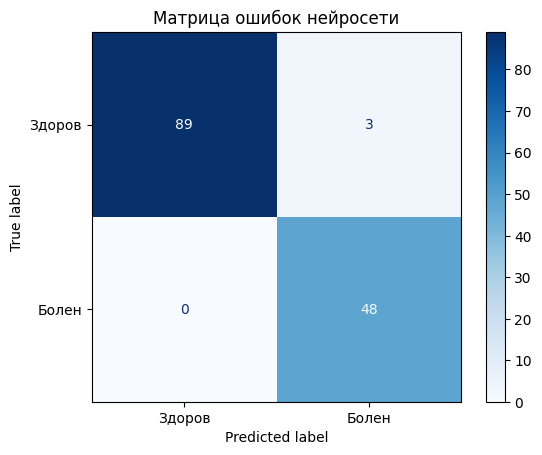

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоров', 'Болен'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Матрица ошибок нейросети')
plt.show()

Рассмотрим точность предсказанных пациентов - больных или не больных

Возьмем первых десятерых

Если на выход 1 - больной человек, иначе здоровый

In [ ]:
for i in range(10):
  input_data = X_test[i]
  target_data = y_test[i]

  x_bias = np.append(input_data, -1)
  u = sigmoid(np.dot(x_bias, W1))
  u_bias = np.append(u, -1)
  pred = sigmoid(np.dot(u_bias, W2))

  print(f"Данные пациента №{0}")
  print(f"Выход нейронов: {pred}")
  print(f"Предсказанный класс: {np.argmax(pred)}")
  print(f"Реальный класс:      {np.argmax(target_data)}")

  if np.argmax(pred) == np.argmax(target_data):
      print("Все ок\n")
  else:
      print("Не ок\n")

Данные пациента №0
Выход нейронов: [0.01174819 0.98836191]
Предсказанный класс: 1
Реальный класс:      1
Все ок

Данные пациента №0
Выход нейронов: [0.98437089 0.01563648]
Предсказанный класс: 0
Реальный класс:      0
Все ок

Данные пациента №0
Выход нейронов: [0.90970552 0.09062098]
Предсказанный класс: 0
Реальный класс:      0
Все ок

Данные пациента №0
Выход нейронов: [0.99826823 0.0017343 ]
Предсказанный класс: 0
Реальный класс:      0
Все ок

Данные пациента №0
Выход нейронов: [0.01949073 0.980318  ]
Предсказанный класс: 1
Реальный класс:      1
Все ок

Данные пациента №0
Выход нейронов: [0.02708026 0.97256026]
Предсказанный класс: 1
Реальный класс:      1
Все ок

Данные пациента №0
Выход нейронов: [0.95175293 0.0482371 ]
Предсказанный класс: 0
Реальный класс:      0
Все ок

Данные пациента №0
Выход нейронов: [0.99782389 0.00217477]
Предсказанный класс: 0
Реальный класс:      0
Все ок

Данные пациента №0
Выход нейронов: [0.99462373 0.00538934]
Предсказанный класс: 0
Реальный класс